In [15]:
import sys
from pathlib import Path

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import BEST_MODEL, DATASET_DIR

print("BEST_MODEL:", BEST_MODEL, "| exists:", BEST_MODEL.exists())
print("DATASET_DIR:", DATASET_DIR)

BEST_MODEL: C:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\models\trained\best.pt | exists: True
DATASET_DIR: C:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\data\asl_yolo


In [16]:
from ultralytics import YOLO

best = YOLO(str(BEST_MODEL))
print("✅ Model loaded successfully")

✅ Model loaded successfully


In [2]:
import sys
from pathlib import Path

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import RUNS_DIR, TRAINED_MODELS_DIR, BEST_MODEL, DATA_YAML, DATASET_DIR

print("RUNS_DIR:", RUNS_DIR)
print("TRAINED_MODELS_DIR:", TRAINED_MODELS_DIR)
print("BEST_MODEL target:", BEST_MODEL)
print("DATA_YAML exists:", DATA_YAML.exists())

RUNS_DIR: C:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\runs
TRAINED_MODELS_DIR: C:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\models\trained
BEST_MODEL target: C:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\models\trained\best.pt
DATA_YAML exists: True


In [3]:
PLOTS_DIR = PROJECT_ROOT / "outputs" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print("✅ PLOTS_DIR:", PLOTS_DIR)

✅ PLOTS_DIR: c:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\outputs\plots


In [6]:
import shutil

RUN_NAME = "asl_yolo_train"  
run_dir = RUNS_DIR / RUN_NAME 
weights_dir = run_dir / "weights"
best_src = weights_dir / "best.pt"
last_src = weights_dir / "last.pt"

print("Run dir:", run_dir, "| exists:", run_dir.exists())
print("Weights dir:", weights_dir, "| exists:", weights_dir.exists())
print("best.pt:", best_src, "| exists:", best_src.exists())
print("last.pt:", last_src, "| exists:", last_src.exists())

TRAINED_MODELS_DIR.mkdir(parents=True, exist_ok=True)

if not best_src.exists():
    raise FileNotFoundError("❌ best.pt not found. Check RUN_NAME or training output folder.")

shutil.copy2(best_src, BEST_MODEL)
print("✅ Copied best.pt to:", BEST_MODEL)

# optional: copy last.pt too
if last_src.exists():
    shutil.copy2(last_src, TRAINED_MODELS_DIR / "last.pt")
    print("✅ Copied last.pt to:", TRAINED_MODELS_DIR / "last.pt")

Run dir: C:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\runs\asl_yolo_train | exists: True
Weights dir: C:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\runs\asl_yolo_train\weights | exists: True
best.pt: C:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\runs\asl_yolo_train\weights\best.pt | exists: True
last.pt: C:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\runs\asl_yolo_train\weights\last.pt | exists: True
✅ Copied best.pt to: C:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\models\trained\best.pt
✅ Copied last.pt to: C:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\models\trained\last.pt


In [7]:
import pandas as pd

csv_path = run_dir / "results.csv"
print("results.csv:", csv_path, "| exists:", csv_path.exists())

if not csv_path.exists():
    raise FileNotFoundError("❌ results.csv not found. Paste the contents of run_dir and I’ll locate the logs.")

df = pd.read_csv(csv_path)
print("Columns:", list(df.columns))
df.head()

results.csv: C:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\runs\asl_yolo_train\results.csv | exists: True
Columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,97.2547,0.60462,4.08570,0.97205,0.03145,0.64298,0.11944,0.10890,0.49776,3.85049,0.83591,0.000109,0.000109,0.000109
1,2,205.4640,0.52824,3.56871,0.89652,0.24099,0.40639,0.24968,0.22565,0.51522,3.13292,0.87484,0.000198,0.000198,0.000198
2,3,332.6570,0.51213,3.11474,0.89550,0.17782,0.54935,0.35364,0.32031,0.53580,2.69665,0.89809,0.000266,0.000266,0.000266
3,4,463.8860,0.50687,2.73709,0.89051,0.37065,0.53706,0.48311,0.43223,0.54856,2.40990,0.89900,0.000234,0.000234,0.000234
4,5,582.9470,0.48499,2.43876,0.87193,0.35050,0.64609,0.52249,0.47286,0.50727,2.27427,0.86867,0.000201,0.000201,0.000201


In [10]:
import matplotlib.pyplot as plt

#Matplotlib plot helpers (saves every plot)
#making functions for plotting and saving
#maintain garna ra resuse garna sajilo huncha

def save_fig(filename: str):
    out = PLOTS_DIR / filename
    plt.savefig(out, dpi=200, bbox_inches="tight")
    print("💾 Saved:", out)

def plot_series(cols, title, filename, ylabel="value"):
    plt.figure()
    found_any = False
    for c in cols:
        if c in df.columns:
            plt.plot(df[c].values, label=c)
            found_any = True
        else:
            print("⚠️ Missing column:", c)
    if not found_any:
        raise ValueError("None of the requested columns exist in results.csv. Ultralytics column names may differ.")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    save_fig(filename)
    plt.show()
   

💾 Saved: c:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\outputs\plots\loss_curves.png


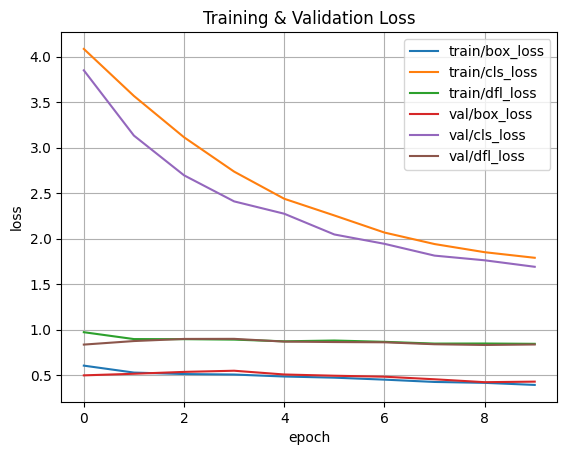

In [11]:
loss_cols = [
    "train/box_loss", "train/cls_loss", "train/dfl_loss",
    "val/box_loss", "val/cls_loss", "val/dfl_loss"
]
plot_series(loss_cols, "Training & Validation Loss", "loss_curves.png", ylabel="loss")

💾 Saved: c:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\outputs\plots\precision_recall.png


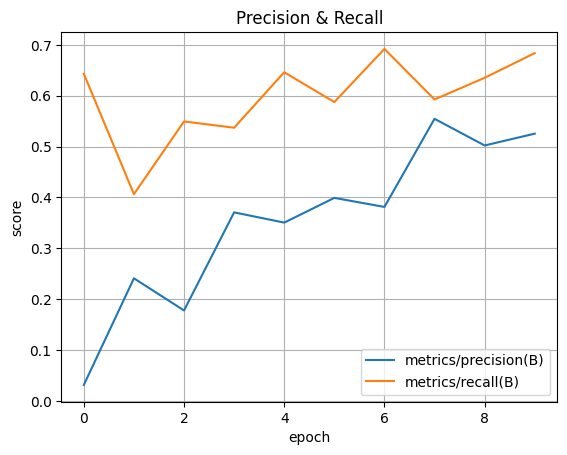

In [12]:
pr_cols = ["metrics/precision(B)", "metrics/recall(B)"]
plot_series(pr_cols, "Precision & Recall", "precision_recall.png", ylabel="score")

💾 Saved: c:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\outputs\plots\map_metrics.png


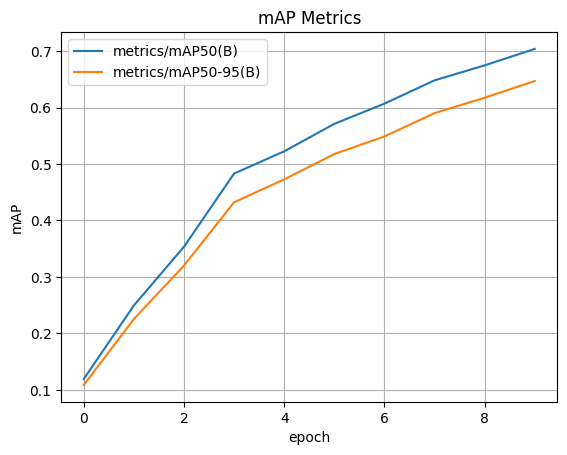

In [13]:
map_cols = ["metrics/mAP50(B)", "metrics/mAP50-95(B)"]
plot_series(map_cols, "mAP Metrics", "map_metrics.png", ylabel="mAP")

In [17]:
import random

pred_out = PROJECT_ROOT / "outputs" / "predictions"
pred_out.mkdir(parents=True, exist_ok=True)

test_img_dir = DATASET_DIR / "test" / "images"
imgs = [p for p in test_img_dir.iterdir() if p.suffix.lower() in [".jpg", ".jpeg", ".png"]]
print("Test images available:", len(imgs))

sample = random.sample(imgs, k=min(10, len(imgs)))

best.predict(
    source=[str(p) for p in sample],
    imgsz=416,
    device="cpu",
    save=True,
    project=str(pred_out),
    name="sample_preds",
    exist_ok=True
)

print("✅ Saved annotated predictions to:", pred_out / "sample_preds")

Test images available: 72

0: 416x416 1 E, 58.9ms
1: 416x416 1 O, 58.9ms
2: 416x416 1 W, 58.9ms
3: 416x416 1 C, 1 P, 58.9ms
4: 416x416 1 R, 58.9ms
5: 416x416 1 A, 58.9ms
6: 416x416 1 H, 1 P, 58.9ms
7: 416x416 1 A, 1 M, 58.9ms
8: 416x416 1 C, 1 O, 1 Q, 58.9ms
9: 416x416 1 Y, 58.9ms
Speed: 5.9ms preprocess, 58.9ms inference, 9.7ms postprocess per image at shape (1, 3, 416, 416)
Results saved to C:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\outputs\predictions\sample_preds
✅ Saved annotated predictions to: c:\Users\dipes\OneDrive\Documents\Machine Learning\Python\Sign_Language\sign_language_detection_new\outputs\predictions\sample_preds
